# Quant backtests — interactive walkthrough

Two strategies, sharing the cleaned loaders in `src/`:

1. **Risk-On vs Risk-Off pairs trade** — z-score mean reversion on a basket spread.
2. **Multi-timeframe breakout** — trend-gated breakout with ATR brackets.

*Research backtests only — no costs/slippage modelled.* See the repo README for the project history and the two bug fixes that this cleaned version incorporates.

In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt

from data import download_closes, download_ohlcv
from pairs_trade import build_spread, zscore, backtest_spread
from breakout import add_signals, backtest_breakout

Matplotlib is building the font cache; this may take a moment.


## Part A — Risk-On vs Risk-Off pairs trade

Build inverse-volatility-weighted baskets, form the spread, z-score it, and mean-revert: short when z > 2, long when z < -2, flatten near 0.

In [2]:
long_tickers = ["ARKK", "COIN", "TSLA", "NVDA"]
short_tickers = ["XLP", "XLU", "TLT", "GLD"]

closes = download_closes(long_tickers + short_tickers, start="2023-01-01")
returns = closes.pct_change(fill_method=None).dropna()

spread = build_spread(returns, long_tickers, short_tickers)
spread_z = zscore(spread)
equity = backtest_spread(spread, spread_z, entry_z=2.0, exit_z=0.5)

print(f"{len(returns)} days; final cumulative PnL: {equity.iloc[-1]:+.4f}")

858 days; final cumulative PnL: +2.2964


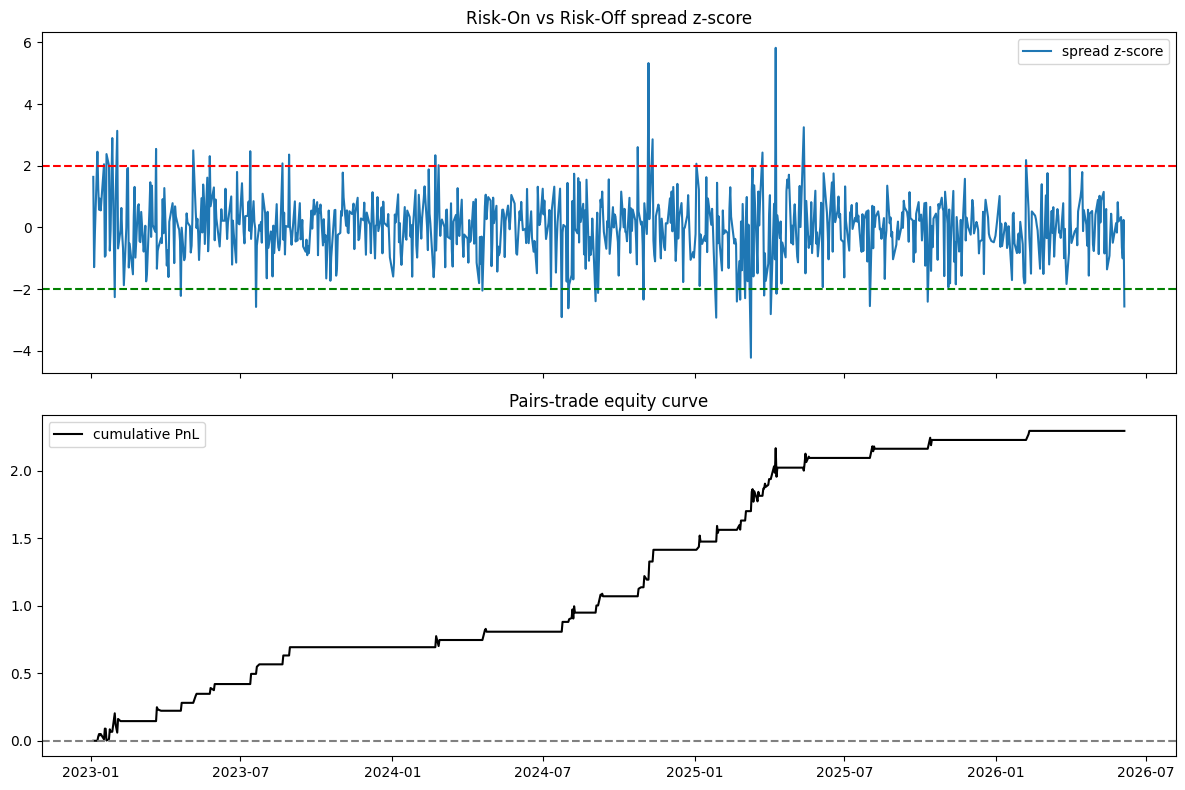

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax1.plot(spread_z.index, spread_z, label="spread z-score")
ax1.axhline(2, color="red", ls="--"); ax1.axhline(-2, color="green", ls="--")
ax1.set_title("Risk-On vs Risk-Off spread z-score"); ax1.legend()
ax2.plot(equity.index, equity, color="black", label="cumulative PnL")
ax2.axhline(0, color="grey", ls="--")
ax2.set_title("Pairs-trade equity curve"); ax2.legend()
plt.tight_layout(); plt.show()

## Part B — Multi-timeframe breakout

Long high-beta names when the daily *and* weekly trend are up and a bullish breakout fires, with a 2:1 ATR take-profit / stop-loss bracket and a time-stop. This is the strategy the original notebook could never run because of the yfinance MultiIndex-column bug, now fixed in `src/data.py`.

In [4]:
tickers = ["NVDA", "AMD", "META", "SHOP", "TSLA"]
curves = {}

for ticker in tickers:
    df = download_ohlcv(ticker, start="2023-01-01", end="2025-07-01")
    if df.empty:
        print(f"{ticker}: no data"); continue
    trades = backtest_breakout(add_signals(df))
    if trades.empty:
        print(f"{ticker}: 0 trades"); continue
    win_rate = (trades["result"] == "TP").mean()
    print(f"{ticker}: {len(trades)} trades, win rate {win_rate:.0%}, total PnL ${trades['pnl'].sum():+.2f}")
    curves[ticker] = trades["pnl"].cumsum()

NVDA: 64 trades, win rate 34%, total PnL $+33.07


AMD: 50 trades, win rate 38%, total PnL $+55.71


META: 71 trades, win rate 34%, total PnL $+264.14


SHOP: 48 trades, win rate 17%, total PnL $-19.15


TSLA: 50 trades, win rate 38%, total PnL $+165.44


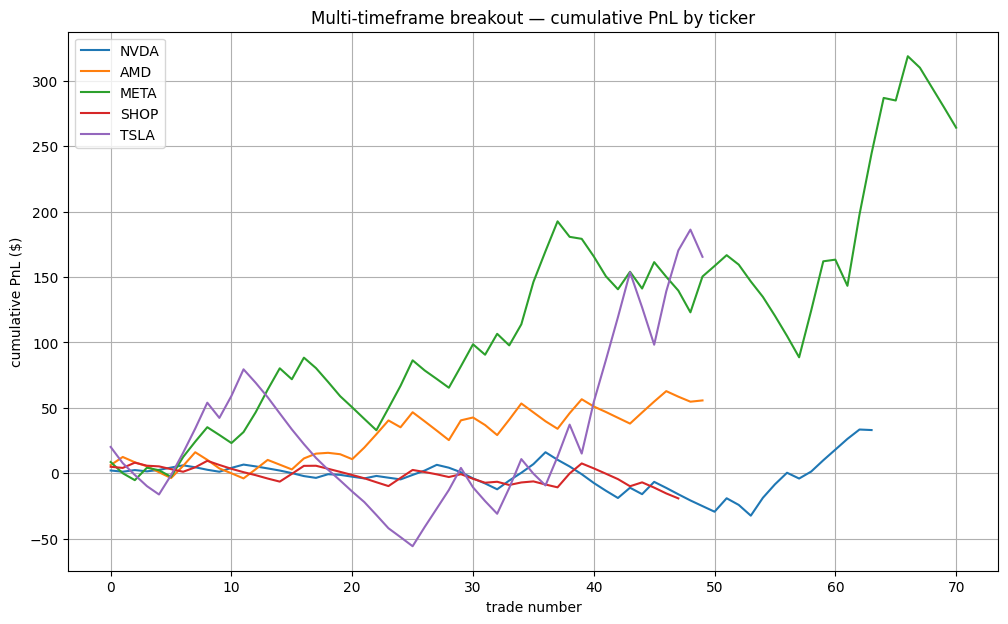

In [5]:
plt.figure(figsize=(12, 7))
for ticker, pnl in curves.items():
    plt.plot(pnl.values, label=ticker)
plt.xlabel("trade number"); plt.ylabel("cumulative PnL ($)")
plt.title("Multi-timeframe breakout — cumulative PnL by ticker")
plt.legend(); plt.grid(True); plt.show()

Note how each ticker can finish net-positive while winning fewer than half its trades — that's the 2:1 ATR take-profit/stop-loss ratio at work.